# Notebook 01: Data Exploration
EDA on raw data: missing values, revenue distributions, country analysis, product analysis, purchase timing.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

from src.data_cleaning import load_raw

df = load_raw('data/raw/Online Retail.xlsx')
print(f'Shape: {df.shape}')
print(df.dtypes)
df.head(10)

Shape: (541909, 8)
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


## 1. Missing Values and Data Quality

In [2]:
# Missing values
print(df.isnull().sum())
print(f"\n% missing CustomerID: {df['CustomerID'].isna().mean()*100:.1f}%")

# Cancellations (InvoiceNo starting with 'C')
invoice_upper = df['InvoiceNo'].astype(str).str.upper().str.strip()
cancelled_mask = invoice_upper.str.startswith('C')
print(f"Cancellation rows: {cancelled_mask.sum():,} ({cancelled_mask.mean()*100:.1f}%)")

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

% missing CustomerID: 24.9%


Cancellation rows: 9,288 (1.7%)


## 2. Revenue and Basic Statistics

In [3]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Quantity:', df['Quantity'].describe())
print('\nUnitPrice:', df['UnitPrice'].describe())
print('\nRevenue (line):', df['Revenue'].describe())

Quantity: count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

UnitPrice: count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

Revenue (line): count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64


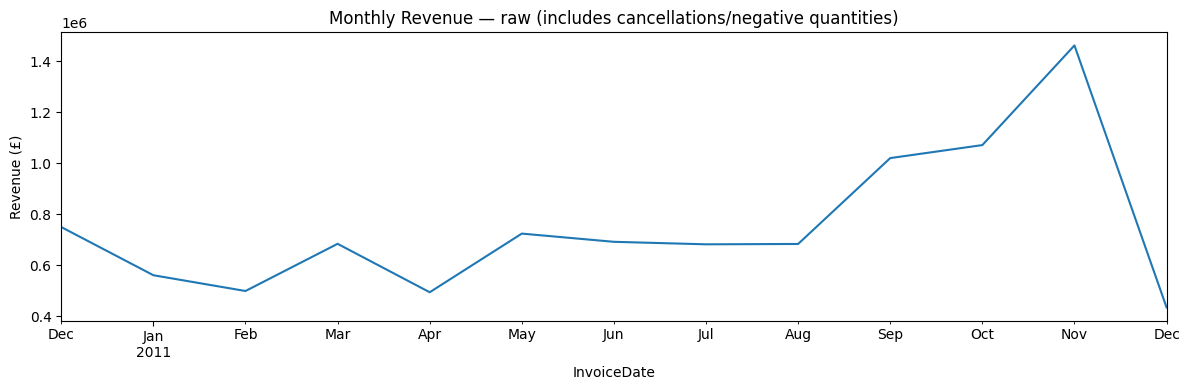

In [4]:
# Monthly revenue trend (raw transactions, including cancellations/returns)
monthly = df.set_index('InvoiceDate')['Revenue'].resample('ME').sum()
fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax)
ax.set_title('Monthly Revenue — raw (includes cancellations/negative quantities)')
ax.set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

## 3. Geographic Analysis

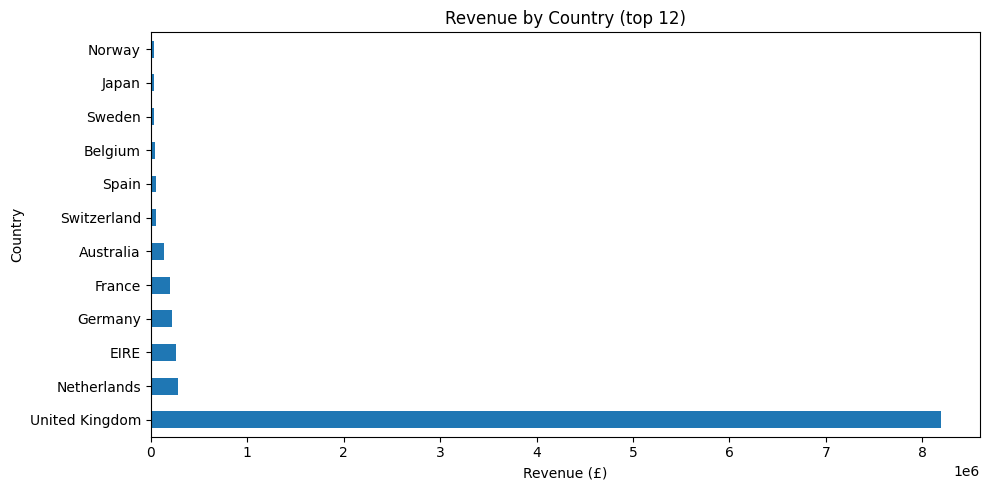

In [5]:
# Top countries by total revenue
by_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(12)
by_country.plot(kind='barh', figsize=(10, 5))
plt.title('Revenue by Country (top 12)')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.show()

### 4. Cancellation analysis by country and product

The chart above uses **raw** revenue, including cancellations and negative quantities. Below, we explore which countries and products appear most often in cancellation rows.

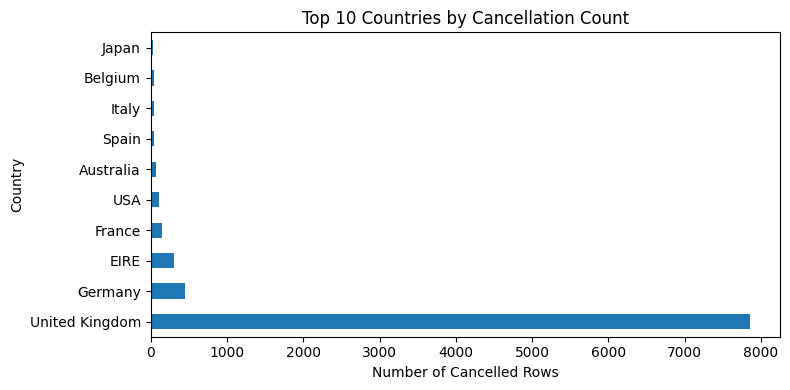

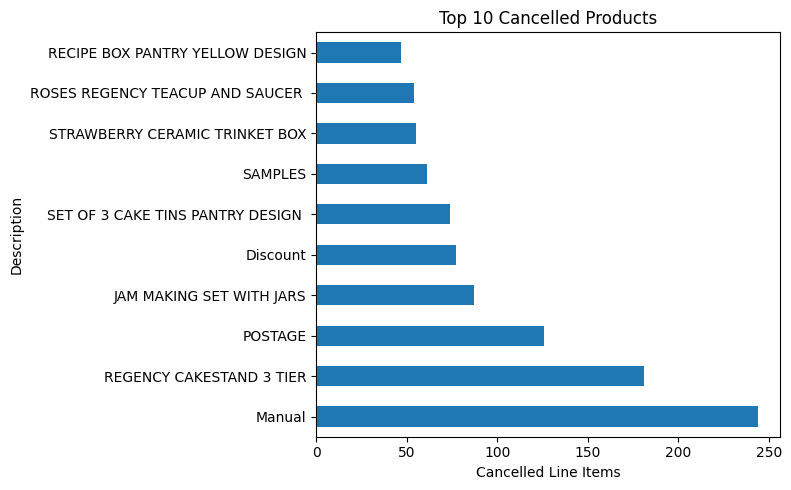

In [6]:
# Top countries by cancellation count
cancelled_df = df[cancelled_mask].copy()
by_country_cancel = cancelled_df['Country'].value_counts().head(10)
by_country_cancel.plot(kind='barh', figsize=(8, 4))
plt.title('Top 10 Countries by Cancellation Count')
plt.xlabel('Number of Cancelled Rows')
plt.tight_layout()
plt.show()

# Top cancelled products
if 'Description' in cancelled_df.columns:
    top_cancelled_products = cancelled_df['Description'].value_counts().head(10)
    top_cancelled_products.plot(kind='barh', figsize=(8, 5))
    plt.title('Top 10 Cancelled Products')
    plt.xlabel('Cancelled Line Items')
    plt.tight_layout()
    plt.show()

### 5. Outlier investigation (high-revenue line items)

This mirrors the cleaning pipeline outlier check: we flag extreme line-level revenues (e.g., > £10,000) that are likely wholesale/bulk orders.

In [7]:
high_rev = df[df['Revenue'] > 10000].copy()
print(f"Rows with Revenue > £10,000: {len(high_rev):,}")
if not high_rev.empty:
    total_rev = df['Revenue'].sum()
    print(f"Share of total revenue: {high_rev['Revenue'].sum()/total_rev*100:.1f}%")
    display(high_rev[['InvoiceNo', 'CustomerID', 'Description', 'Quantity', 'Revenue']].head(10))

Rows with Revenue > £10,000: 5
Share of total revenue: 3.2%


,InvoiceNo,CustomerID,Description,Quantity,Revenue
15017,537632,NaN,AMAZON FEE,1,13541.33
61619,541431,12346.0,MEDIUM CERAMIC TOP STORAGE JAR,74215,77183.60
222680,556444,15098.0,PICNIC BASKET WICKER 60 PIECES,60,38970.00
299982,A563185,NaN,Adjust bad debt,1,11062.06
540421,581483,16446.0,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60


### 6. Rich EDA on cleaned data (optional)

If you have already run **Notebook 02 (Data Cleaning)** or the Python script `src/run_data_pipeline.py`, a cleaned version of the dataset will exist at `data/preprocessed/online_retail_preprocessed.csv`. We can reuse that plus the RFM output to generate the full set of EDA charts using the reusable helpers in `src.visualizations`.

In [8]:
import os
from src.visualizations import generate_all_eda_charts

preprocessed_path = 'data/preprocessed/online_retail_preprocessed.csv'
rfm_path = 'data/featured/customer_rfm.csv'

if os.path.exists(preprocessed_path) and os.path.exists(rfm_path):
    df_pre = pd.read_csv(preprocessed_path)
    rfm_pre = pd.read_csv(rfm_path)
    generate_all_eda_charts(df_pre, rfm_pre, save_dir='images/eda_charts')
else:
    print('Preprocessed/RFM data not found yet. Run Notebook 02 and 03 or the pipeline script first.')

Generating EDA charts...
  ✓ monthly_revenue.png


  ✓ revenue_by_country.png
  ✓ revenue_per_customer_by_country.png
  ✓ top_products_revenue.png


  ✓ top_products_quantity.png
  ✓ day_hour_patterns.png


  ✓ rfm_distributions.png
  ✓ order_frequency_distribution.png
  ✓ segment_distribution.png
  ✓ revenue_by_segment.png


  ✓ segment_scatter.png
  ✓ pareto_curve.png
Done — 12 charts saved to images/eda_charts/
